In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

In [2]:
#Load Dataset
df = pd.read_csv("heart.csv")

print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [3]:
print(df.shape)

(1025, 14)


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [5]:
#Separate Features and Target
X = df.drop("target", axis=1)
y = df["target"]

In [6]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
#Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred))

Decision Tree Accuracy: 0.9853658536585366


In [8]:
#Confusion Matrix
print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



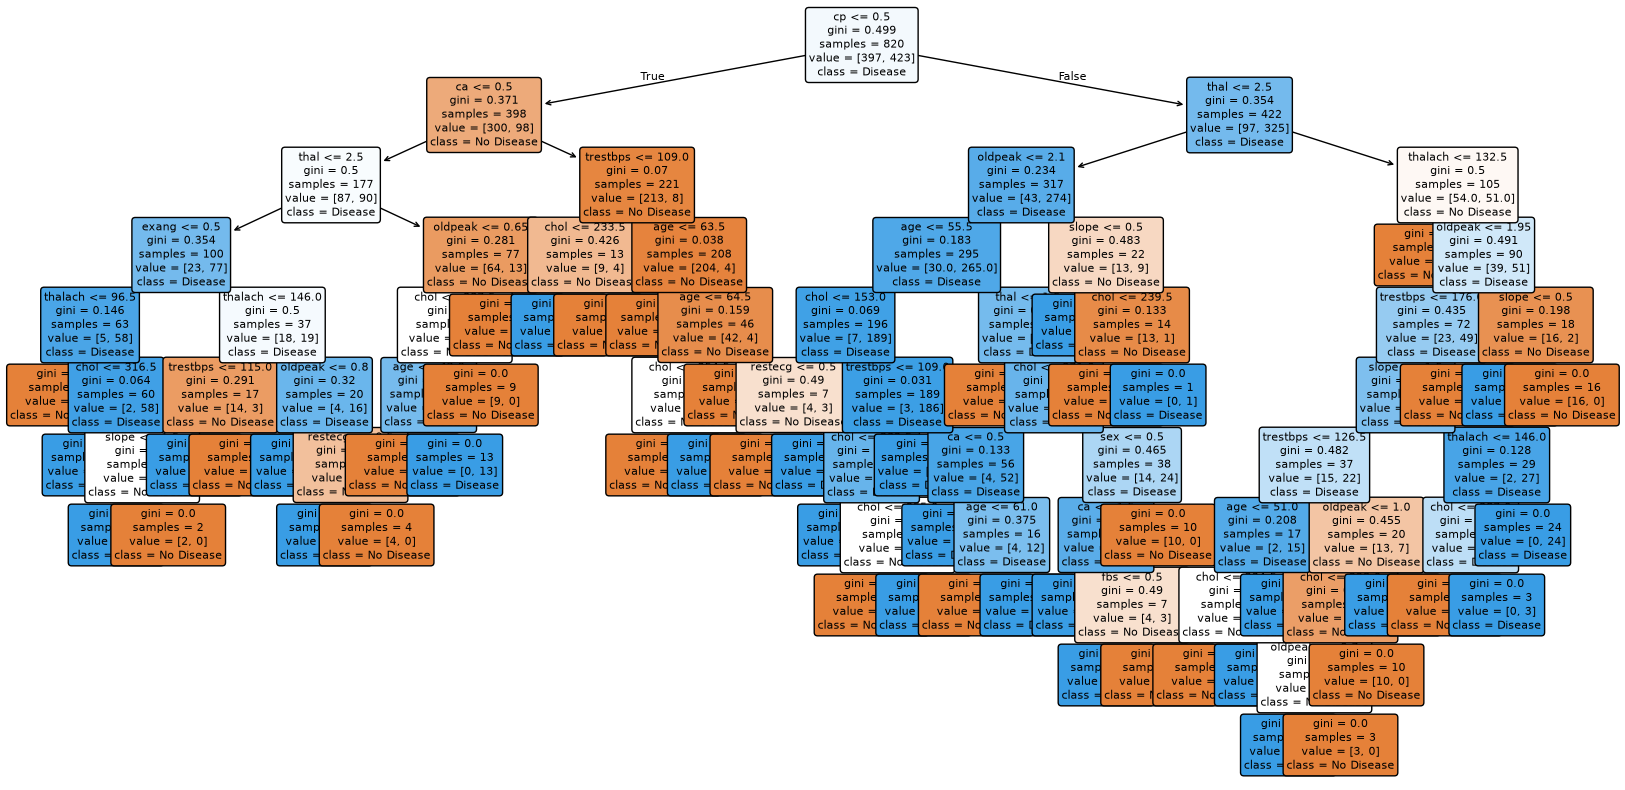

In [9]:
#Visualize Decision Tree
plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Disease","Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

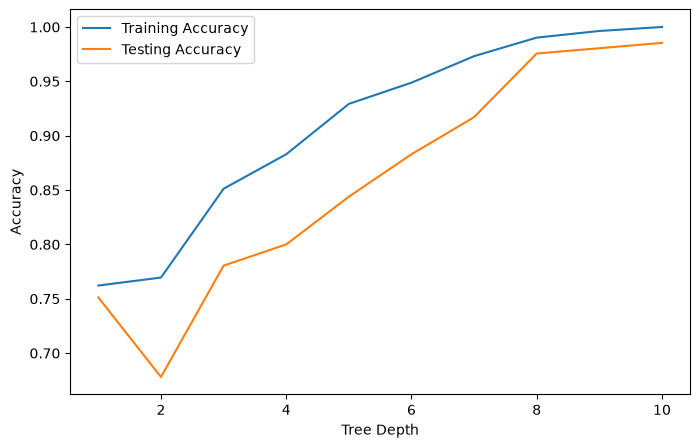

In [10]:
train_acc = []
test_acc = []

depths = range(1,11)

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train,y_train)

    train_acc.append(model.score(X_train,y_train))
    test_acc.append(model.score(X_test,y_test))

plt.figure(figsize=(8,5))

plt.plot(depths,train_acc,label="Training Accuracy")
plt.plot(depths,test_acc,label="Testing Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Observation

Small depth → Underfitting, 
Very large depth → Overfitting, 
Best depth usually lies between 3–6 for many heart disease datasets.

In [11]:
#Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test,rf_pred))

Random Forest Accuracy: 0.9853658536585366


In [12]:
#Confusion Matrix
print(confusion_matrix(y_test,rf_pred))

print(classification_report(y_test,rf_pred))

[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [13]:
#Compare Accuracy
print("Decision Tree Accuracy :",
      accuracy_score(y_test,y_pred))

print("Random Forest Accuracy :",
      accuracy_score(y_test,rf_pred))

Decision Tree Accuracy : 0.9853658536585366
Random Forest Accuracy : 0.9853658536585366


In [14]:
#Feature Importance
importance = pd.DataFrame({

    "Feature":X.columns,
    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


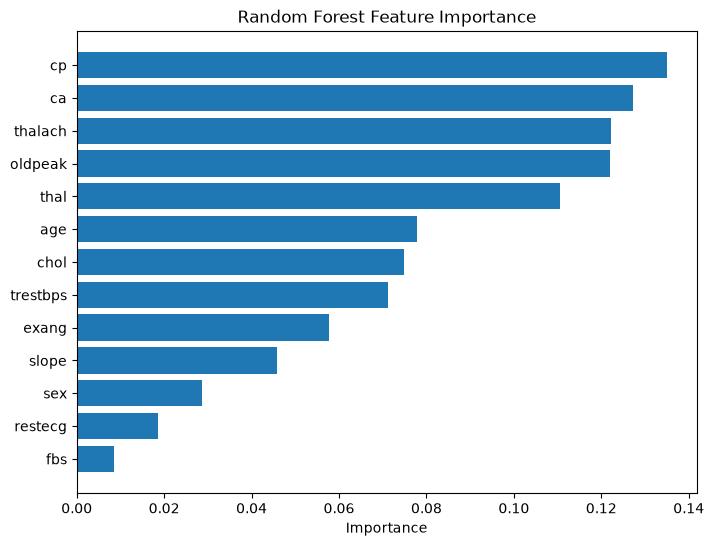

In [15]:
#Plot Feature Importance
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [16]:
#Decision Tree
dt_scores = cross_val_score(
    dt,
    X,
    y,
    cv=5
)

print("Decision Tree CV Accuracy:")
print(dt_scores)

print("Mean:",
      dt_scores.mean())

Decision Tree CV Accuracy:
[1. 1. 1. 1. 1.]
Mean: 1.0


In [17]:
#Random Forest
rf_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Random Forest CV Accuracy:")
print(rf_scores)

print("Mean:",
      rf_scores.mean())

Random Forest CV Accuracy:
[1.         1.         1.         1.         0.98536585]
Mean: 0.9970731707317073
